# Evaluación de Random Forest (Scikit-Learn)

Este notebook selecciona una configuración por **F1 macro medio anual** mediante
`RandomizedSearchCV` para un clasificador `RandomForestClassifier` de scikit-learn,
utilizando **los mismos folds temporales** que el modelo de árbol de decisión manual.

Toda la validación cruzada utiliza exclusivamente `train` (partidos anteriores al 1 de enero de 2024).
El conjunto `test` queda reservado y no se utiliza en esta etapa.

In [1]:
# 1. Carga del dataset y definición de atributos
import pandas as pd
from load import load_dataset
from pipeline import pipeline_input_attributes

dataset = load_dataset("futbol_uruguayo.csv")
print("Primeras filas del dataset:")
print(dataset.head())

Primeras filas del dataset:
                   home                              away       date  gh  ga  \
0           Bella Vista                 Defensor Sporting 1932-03-05   1   2   
1            CA Penarol                       River Plate 1932-03-05   1   1   
2       Central Espanol        Rampla Juniors Futbol Club 1932-03-05   1   0   
3  Montevideo Wanderers                       Racing Club 1932-03-05   3   0   
4              Nacional  Institucion Atletica Sud America 1932-03-05   2   0   

  result  record_difference  last_matches_difference  goal_difference_value  \
0      V                0.0                      0.0                    0.0   
1      E                0.0                      0.0                    0.0   
2      L                0.0                      0.0                    0.0   
3      L                0.0                      0.0                    0.0   
4      L                0.0                      0.0                    0.0   

   attack_differ

In [2]:
# 2. Separación temporal entre desarrollo (train) y test
test_start = pd.Timestamp("2024-01-01")

train = dataset[dataset["date"] < test_start].copy()
test = dataset[dataset["date"] >= test_start].copy()

assert not train.empty, "El conjunto de entrenamiento está vacío"
assert (train["date"] < test_start).all()
assert (test["date"] >= test_start).all()

print("Partidos para entrenamiento y validación cruzada:", len(train))
print("Partidos de test reservados desde 2024 (sin evaluar):", len(test))

X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

Partidos para entrenamiento y validación cruzada: 14734
Partidos de test reservados desde 2024 (sin evaluar): 472


In [3]:
# 3. Construcción de los folds temporales idénticos a los del árbol manual
import numpy as np

validation_years = list(range(2013, 2023))
train_years = train["date"].dt.year.to_numpy()
window_years = 5
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    assert len(fit_indices) > 0 and len(validation_indices) > 0, "Fold vacío"
    assert train.iloc[fit_indices]["date"].max() < train.iloc[validation_indices]["date"].min()
    assert (train.iloc[validation_indices]["date"] < test_start).all()

    temporal_splits.append((fit_indices, validation_indices))
    print(f"Validación {validation_year}: entrenamiento={len(fit_indices)}, validación={len(validation_indices)}")

Validación 2013: entrenamiento=1231, validación=241
Validación 2014: entrenamiento=1221, validación=243
Validación 2015: entrenamiento=1209, validación=241
Validación 2016: entrenamiento=1207, validación=240
Validación 2017: entrenamiento=1206, validación=302
Validación 2018: entrenamiento=1267, validación=261
Validación 2019: entrenamiento=1287, validación=299
Validación 2020: entrenamiento=1343, validación=175
Validación 2021: entrenamiento=1277, validación=367
Validación 2022: entrenamiento=1404, validación=298


In [4]:
# 4. Búsqueda de hiperparámetros con Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [None, 5, 8, 12, 15, 20],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8, 12],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy", "log_loss"]
}

selection_metric = "f1_macro"
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    scoring=scoring,
    cv=temporal_splits,
    n_jobs=-1,
    refit=selection_metric,
    random_state=42,
    verbose=1,
)

search_rf.fit(X_train, y_train)

print("\nHiperparámetros seleccionados por F1 macro medio anual (Random Forest):")
print(search_rf.best_params_)
print(f"F1 macro medio anual del ganador: {search_rf.best_score_:.3%}")
best_acc = search_rf.cv_results_["mean_test_accuracy"][search_rf.best_index_]
print(f"Accuracy media anual del mismo ganador: {best_acc:.3%}")
best_balanced_acc = search_rf.cv_results_["mean_test_balanced_accuracy"][search_rf.best_index_]
print(f"Balanced accuracy media anual del mismo ganador: {best_balanced_acc:.3%}")

Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Hiperparámetros seleccionados por F1 macro medio anual (Random Forest):
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None, 'criterion': 'gini'}
F1 macro medio anual del ganador: 38.745%
Accuracy media anual del mismo ganador: 44.522%
Balanced accuracy media anual del mismo ganador: 40.844%


In [5]:
# 5. Tabla de candidatos ordenada por F1 macro medio anual
from IPython.display import display

results_rf = pd.DataFrame(search_rf.cv_results_)
parameter_columns = [col for col in results_rf.columns if col.startswith("param_")]
metric_names = [search_rf.refit] + [m for m in scoring if m != search_rf.refit]
summary_columns = [
    f"{stat}_test_{metric}"
    for metric in metric_names
    for stat in ("mean", "std", "rank")
]

results_rf = results_rf[parameter_columns + summary_columns].sort_values(
    f"rank_test_{search_rf.refit}", kind="stable"
)

print("Primeros 10 candidatos de Random Forest (ordenados por F1 macro):")
display(results_rf.head(10))

Primeros 10 candidatos de Random Forest (ordenados por F1 macro):


,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_criterion,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy
98,50,2,4,NaN,None,gini,0.387449,0.037361,1,0.445218,0.035252,67,0.408440,0.035608,20
8,50,2,2,sqrt,15,gini,0.383934,0.022238,2,0.451297,0.030769,45,0.409841,0.019868,10
48,50,10,1,log2,None,log_loss,0.382436,0.026770,3,0.451604,0.032003,44,0.410625,0.024243,8
38,50,10,2,NaN,20,gini,0.382258,0.021268,4,0.441130,0.025256,84,0.402964,0.022675,62
7,50,5,4,log2,15,gini,0.380653,0.027595,5,0.453584,0.028588,36,0.411811,0.026499,6
72,300,15,8,NaN,None,gini,0.377651,0.027016,6,0.451975,0.028700,42,0.408406,0.025380,21
61,150,15,4,NaN,15,entropy,0.377578,0.024911,7,0.446122,0.026955,64,0.404988,0.023625,52
86,150,10,1,NaN,15,log_loss,0.377461,0.030163,8,0.440584,0.032848,86,0.401259,0.026994,73
5,200,2,1,sqrt,20,gini,0.377189,0.030595,9,0.445051,0.037585,68,0.403260,0.032038,60
54,100,2,2,log2,15,entropy,0.377129,0.034440,10,0.446258,0.037598,63,0.405831,0.033158,44


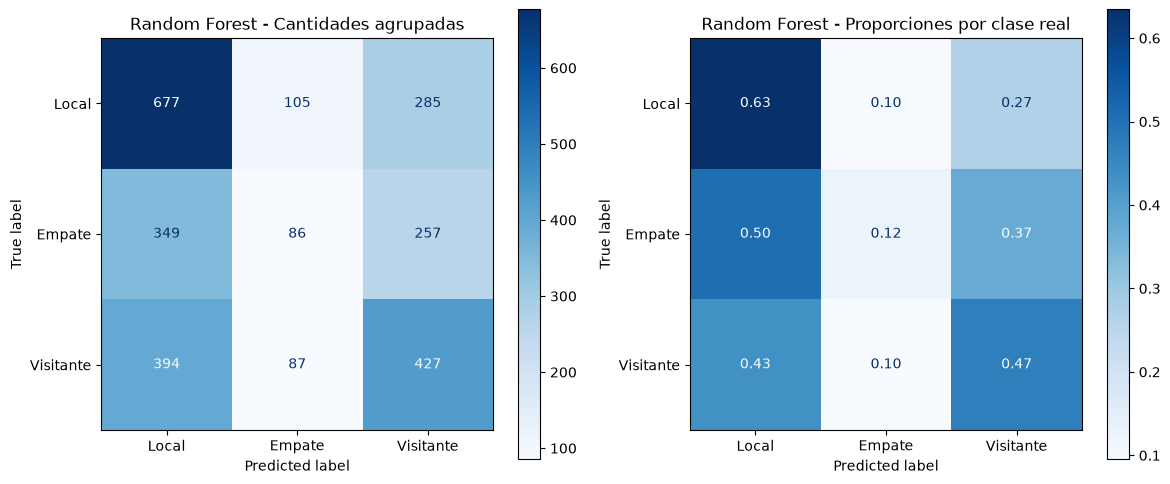

Métricas resumidas de Random Forest:
                   Media anual (CV)  Validación agrupada
F1 macro                    38.745%              39.224%
Accuracy                    44.522%              44.619%
Balanced accuracy           40.844%              40.968%

Reporte por clase (Validación agrupada):
              precision    recall  f1-score   support

       Local       0.48      0.63      0.54      1067
      Empate       0.31      0.12      0.18       692
   Visitante       0.44      0.47      0.45       908

    accuracy                           0.45      2667
   macro avg       0.41      0.41      0.39      2667
weighted avg       0.42      0.45      0.42      2667



In [6]:
# 6. Matrices de confusión y reporte agrupado de validación
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt

real_results = []
predicted_results = []

for fit_indices, validation_indices in temporal_splits:
    fold_model = clone(search_rf.best_estimator_)
    fold_model.fit(X_train.iloc[fit_indices], y_train.iloc[fit_indices])
    fold_predictions = fold_model.predict(X_train.iloc[validation_indices])
    
    real_results.extend(y_train.iloc[validation_indices])
    predicted_results.extend(fold_predictions)

real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)
labels = ["L", "E", "V"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=["Local", "Empate", "Visitante"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)
axes[0].set_title("Random Forest - Cantidades agrupadas")

ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=["Local", "Empate", "Visitante"],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)
axes[1].set_title("Random Forest - Proporciones por clase real")

plt.tight_layout()
plt.show()

metrics_summary = pd.DataFrame({
    "Media anual (CV)": {
        "F1 macro": search_rf.cv_results_["mean_test_f1_macro"][search_rf.best_index_],
        "Accuracy": search_rf.cv_results_["mean_test_accuracy"][search_rf.best_index_],
        "Balanced accuracy": search_rf.cv_results_["mean_test_balanced_accuracy"][search_rf.best_index_],
    },
    "Validación agrupada": {
        "F1 macro": f1_score(real_results, predicted_results, average="macro", zero_division=0),
        "Accuracy": accuracy_score(real_results, predicted_results),
        "Balanced accuracy": balanced_accuracy_score(real_results, predicted_results),
    },
})
print("Métricas resumidas de Random Forest:")
print(metrics_summary.to_string(float_format=lambda v: f"{v:.3%}"))
print("\nReporte por clase (Validación agrupada):")
print(classification_report(
    real_results, predicted_results, labels=labels,
    target_names=["Local", "Empate", "Visitante"], zero_division=0
))

In [7]:
# 7. Registro del experimento en un CSV propio (experimentos_rf.csv)
import csv
import json
from datetime import datetime, timezone
from pathlib import Path
import load

csv_path = Path(load.__file__).resolve().parent / "experimentos_rf.csv"
best_index = search_rf.best_index_
best_parameters = search_rf.best_estimator_.get_params()

experiment = {
    "fecha_utc": datetime.now(timezone.utc).isoformat(),
    "modelo": "RandomForestClassifier",
    "validation_years": json.dumps(validation_years),
    "window_years": window_years,
    "n_train": len(X_train),
    "n_test_reservado": len(test),
    "mejores_parametros": json.dumps(search_rf.best_params_, sort_keys=True),
    "refit": search_rf.refit,
    "cv_accuracy": search_rf.cv_results_["mean_test_accuracy"][best_index],
    "cv_f1_macro": search_rf.cv_results_["mean_test_f1_macro"][best_index],
    "cv_balanced_accuracy": search_rf.cv_results_["mean_test_balanced_accuracy"][best_index],
    "reporte_validacion": classification_report(
        real_results, predicted_results, labels=labels,
        target_names=["Local", "Empate", "Visitante"], zero_division=0,
    ),
    "notas": f"RandomForestClassifier sin discretización; n_iter={search_rf.n_iter}; semilla=42; test sin evaluar",
}

experiment["reporte_validacion"] = " | ".join(
    " ".join(line.split())
    for line in experiment["reporte_validacion"].splitlines() if line.strip()
)

has_header = csv_path.exists() and csv_path.stat().st_size > 0
with csv_path.open("a", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=experiment)
    if not has_header:
        writer.writeheader()
    writer.writerow(experiment)

print(f"Experimento guardado exitosamente en {csv_path}")

Experimento guardado exitosamente en /home/matiasencion/Desktop/AprendizajeAutomatico/Tarea1/dataset/experimentos_rf.csv
